# Separation between FK5 and ICRS

In [64]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from spectral_cube import SpectralCube, Projection
from astropy.modeling import models, fitting
from astropy.convolution import convolve_models
from astropy import units as u
from astropy.io import fits
import radio_beam
from radio_beam import Beam
import pandas as pd
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import pixel_to_skycoord

Code for fitting 2D Gaussians and storing measurements in a table, including SkyCoords.

In [65]:
#Accessing Cube Data
def fit_2dgaussian(directory, maser_table, freq, amplitude, x, y, x_stddev, y_stddev, 
    theta=np.pi/3, size=13, channel=0, cube=True, format='fits', table=True, source_name='None',
    fixed_xstddev=False, fixed_ystddev=False, fixed_theta=False):

    """
    Fit a 2D Gaussian to a cutout of a spectral cube or image.

    """

    if cube:
        
        cube = SpectralCube.read(directory, format=format)

        if channel is None:
            pass
        else:
            cube = cube[channel,:,:]

        cube_cutout = cube[y - size:y + size, x - size:x + size]
        yy, xx = cube_cutout.spatial_coordinate_map

        cord = cube.world[y,x]

        x_guess, y_guess = cord[1], cord[0]

    else:
        
        hdul = fits.open(directory)

        hdu = hdul[0]

        data_cube = hdul[0].data

        if data_cube.ndim == 4:
            data = data_cube[0, 0, :, :] * u.Jy/u.beam

        else:
            data = hdu.data * u.Jy/u.beam

        header = hdu.header

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            ww = WCS(header)

        data_cutout = data[y - size:y + size, x - size:x + size]
        ypixel_grid, xpixel_grid = np.mgrid[y - size:y + size, x - size:x + size]
        
        # xx, yy = ww.pixel_to_world_values(xpixel_grid, ypixel_grid)

        # xx = (xx * u.deg)
        # yy = (yy * u.deg)

        # x_guess, y_guess = xx[size, size], ypixel_grid[size, size]

    p_init_gauss2D = models.Gaussian2D(x_mean=x, y_mean=y, amplitude=amplitude * (u.Jy/u.beam),
                                    x_stddev=(x_stddev), y_stddev=(y_stddev), theta=(theta)*u.rad)

    if fixed_xstddev:
        p_init_gauss2D.x_stddev.fixed = True

    if fixed_ystddev:
        p_init_gauss2D.y_stddev.fixed = True

    if fixed_theta:
        p_init_gauss2D.theta.fixed = True

    fit_p = fitting.LevMarLSQFitter()
    data_cutout[np.isnan(data_cutout)] = 0.

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        p_gauss2D = fit_p(p_init_gauss2D, xpixel_grid, ypixel_grid, data_cutout)

  
    cov = np.diag(fit_p.fit_info['param_cov'])
    errors = np.sqrt(cov)

    amplitude_error=np.format_float_scientific(errors[0],precision=9)
    x_mean_error=np.format_float_scientific(errors[1],precision=9)
    y_mean_error=np.format_float_scientific(errors[2],precision=9)
    x_stddev_error=np.format_float_scientific(errors[3],precision=9)
    y_stddev_error=np.format_float_scientific(errors[4],precision=9)
    theta_error=np.format_float_scientific(errors[5],precision=9)

    amplitude = np.format_float_scientific(p_gauss2D.amplitude[0],precision=9)
    x_mean = np.format_float_scientific(p_gauss2D.x_mean[0],precision=9)
    y_mean = np.format_float_scientific(p_gauss2D.y_mean[0],precision=9)
    x_stddev = np.format_float_scientific(p_gauss2D.x_stddev[0],precision=9)
    y_stddev = np.format_float_scientific(p_gauss2D.y_stddev[0],precision=9)
    theta = np.format_float_scientific(p_gauss2D.theta[0],precision=9)

                
    plt.figure(figsize=(20, 6))
    plt.suptitle(f"Source-{source_name} freq-{freq}", fontsize=18)

    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(data_cutout.value, origin='lower', cmap='inferno')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title("Model")
    plt.imshow(p_gauss2D(xpixel_grid, ypixel_grid).value, origin='lower', cmap='inferno')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title("Residual")
    plt.imshow(data_cutout.value - p_gauss2D(xpixel_grid, ypixel_grid).value, origin='lower', cmap='inferno')
    plt.colorbar(label='S (Jy)')

    plt.show()

    print("Parameter" + ' ' + 'Error' +"\n")
    print("Amplitude" +"\n")
    print(amplitude + ' ' + amplitude_error +"\n")

    print("x_mean"  +"\n")
    print(x_mean + ' ' + x_mean_error +"\n")

    print("y_mean" +"\n")
    print(y_mean + ' ' + y_mean_error +"\n")

    print("x_stddev" +"\n")
    print(x_stddev + ' ' + x_stddev_error +"\n")

    print("y_stddev" +"\n")
    print(y_stddev + ' ' + y_stddev_error +"\n")

    print("theta" +"\n")
    print(theta + ' ' + theta_error +"\n")

    # print('\n\nSkyCoord Conversion \n----------------- \n')
    # print("Parameter" + ' ' + 'Error' +"\n")

    skycoord = pixel_to_skycoord(float(x_mean), float(y_mean), ww)

    # error propagation? # Not sure if this is correct
    skycoord_error = pixel_to_skycoord(float(x_mean_error), float(y_mean_error), ww)


    ra_hms_str = skycoord.ra.to_string(unit=u.hour, sep=':', precision=4)
    dec_dms_str = skycoord.dec.to_string(unit=u.deg, sep=':', precision=4)


    print(skycoord_error)

    if table:
        new_row = pd.DataFrame({'source': [source_name] , 
            'freq': [freq], 'x_pix': [x], 'y_pix': [y], 'amplitude': [amplitude], 
            'amplitude_error': [amplitude_error], 'x_mean': [x_mean], 'x_mean_error': [x_mean_error], 
            'y_mean': [y_mean], 'y_mean_error': [y_mean_error], 
            'x_mean_sky': [skycoord.ra.deg], 'x_mean_sky_error': [skycoord_error.ra.deg],
            'y_mean_sky': [skycoord.dec.deg], 'y_mean_sky_error': [skycoord_error.dec.deg],
            'ra_hms': [ra_hms_str], 'dec_dms': [dec_dms_str],
            'SkyCoord' : [skycoord],
            'frame': [skycoord.frame.name], 
            'header': [ww]})
        maser_table = pd.concat([maser_table, new_row], ignore_index=True)

        return maser_table

### Positions for Sources in FK5 File

In [66]:
ca3_positions = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

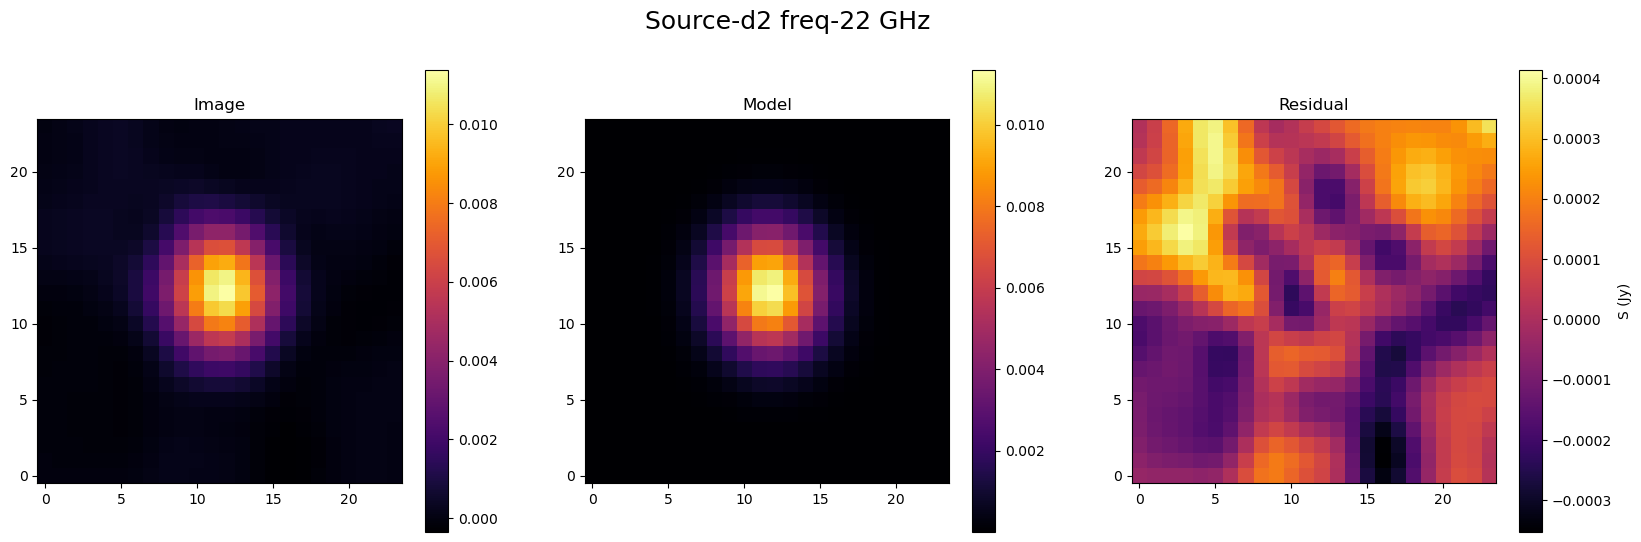

Parameter Error

Amplitude

1.151836792e-02 2.994631787e-04

x_mean

5.218610551e+03 6.144036822e-02

y_mean

4.95918845e+03 7.060362261e-02

x_stddev

2.360699071e+00 6.137510869e-02

y_stddev

2.717842575e+00 7.066038977e-02

theta

-9.343817495e+00 1.300621621e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836823, 14.4973382)>


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/1725868750.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maser_table = pd.concat([maser_table, new_row], ignore_index=True)


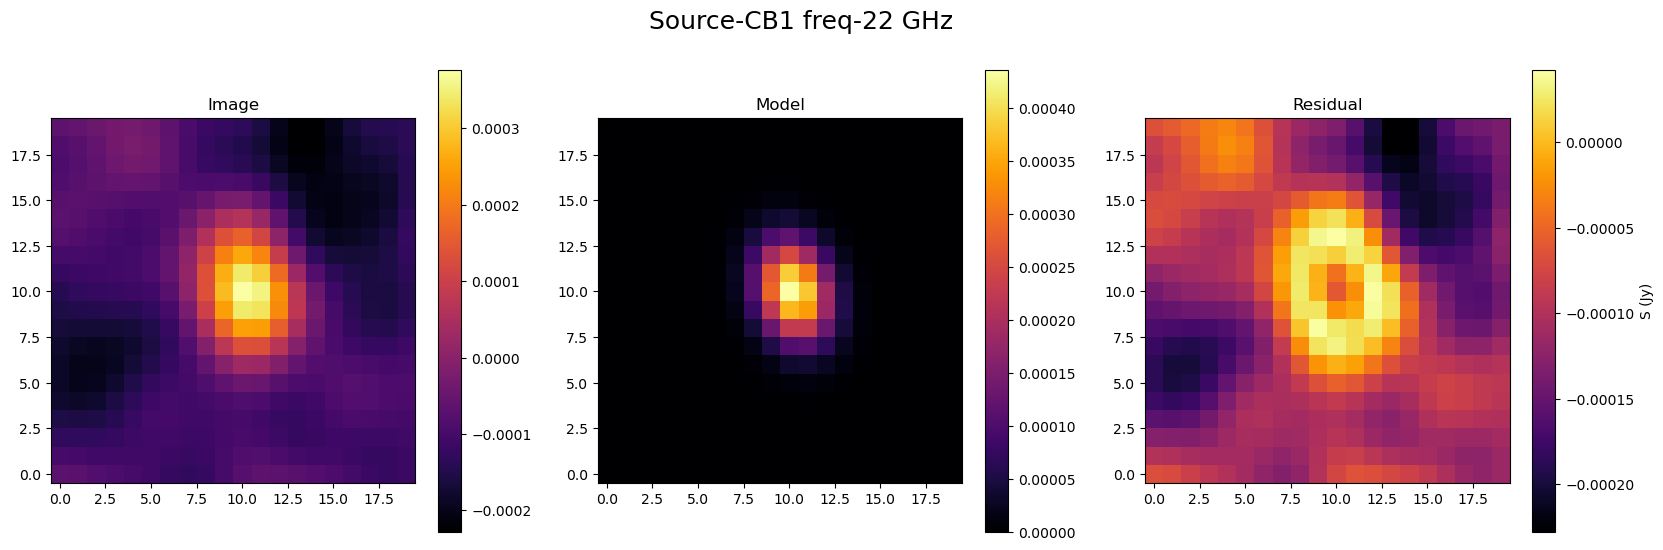

Parameter Error

Amplitude

4.441095342e-04 3.220142691e-04

x_mean

4.979244419e+03 9.860078561e-01

y_mean

5.000022628e+03 1.336618399e+00

x_stddev

1.31342064e+00 9.527568593e-01

y_stddev

1.875751231e+00 1.360519841e+00

theta

2.645735497e-01 1.409406674e+00

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836425, 14.49734347)>


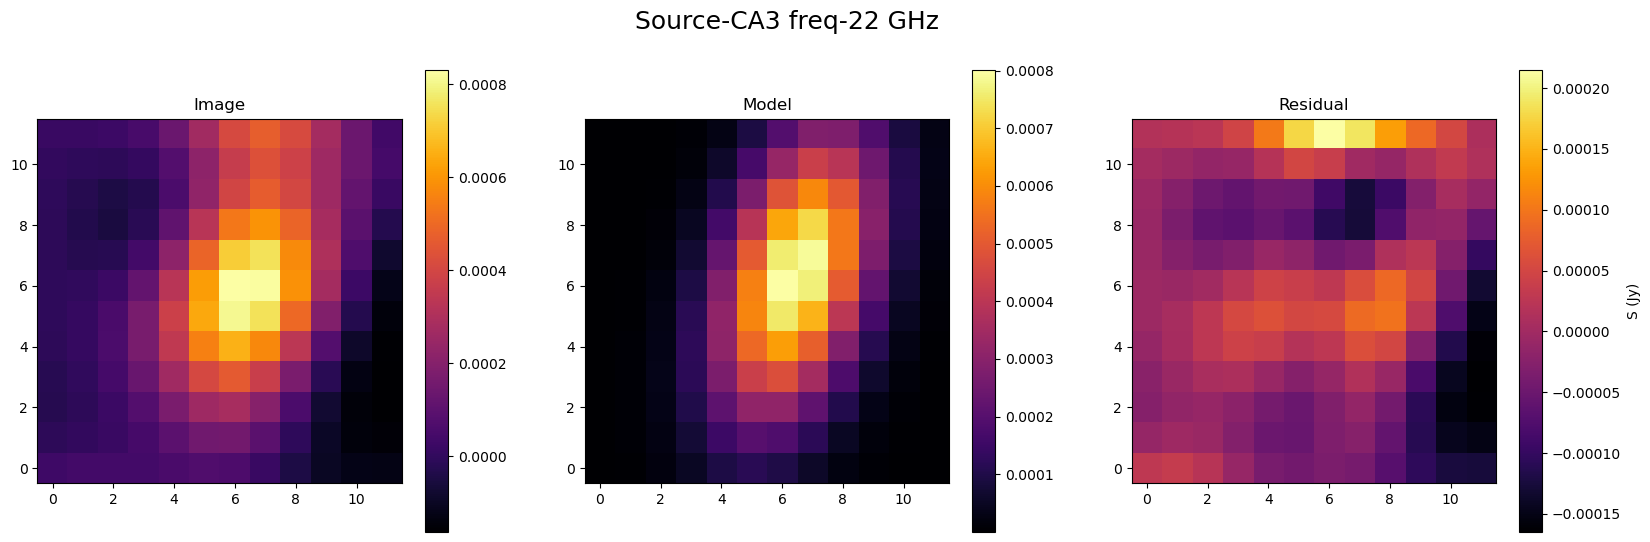

Parameter Error

Amplitude

8.286839918e-04 1.202250481e-04

x_mean

4.948462022e+03 2.543054466e-01

y_mean

5.015367510e+03 4.805084936e-01

x_stddev

3.316473831e+00 5.583814501e-01

y_stddev

1.585978639e+00 2.253348706e-01

theta

1.071569561e+01 1.303415909e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.9383674, 14.49733991)>


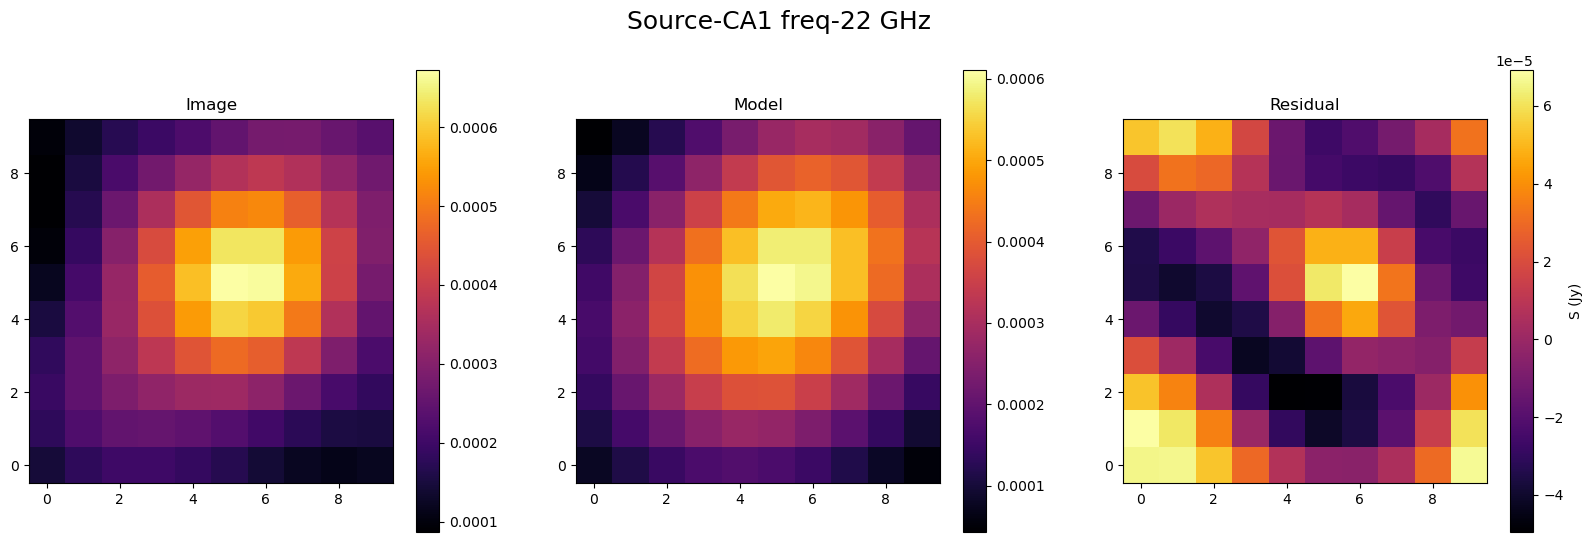

Parameter Error

Amplitude

6.131044792e-04 4.511103321e-05

x_mean

4.929290048e+03 2.572806573e-01

y_mean

5.023102075e+03 2.51185041e-01

x_stddev

3.640306692e+00 3.552392274e-01

y_stddev

2.839413584e+00 2.384574681e-01

theta

7.750857357e-01 2.728536159e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836739, 14.49733895)>


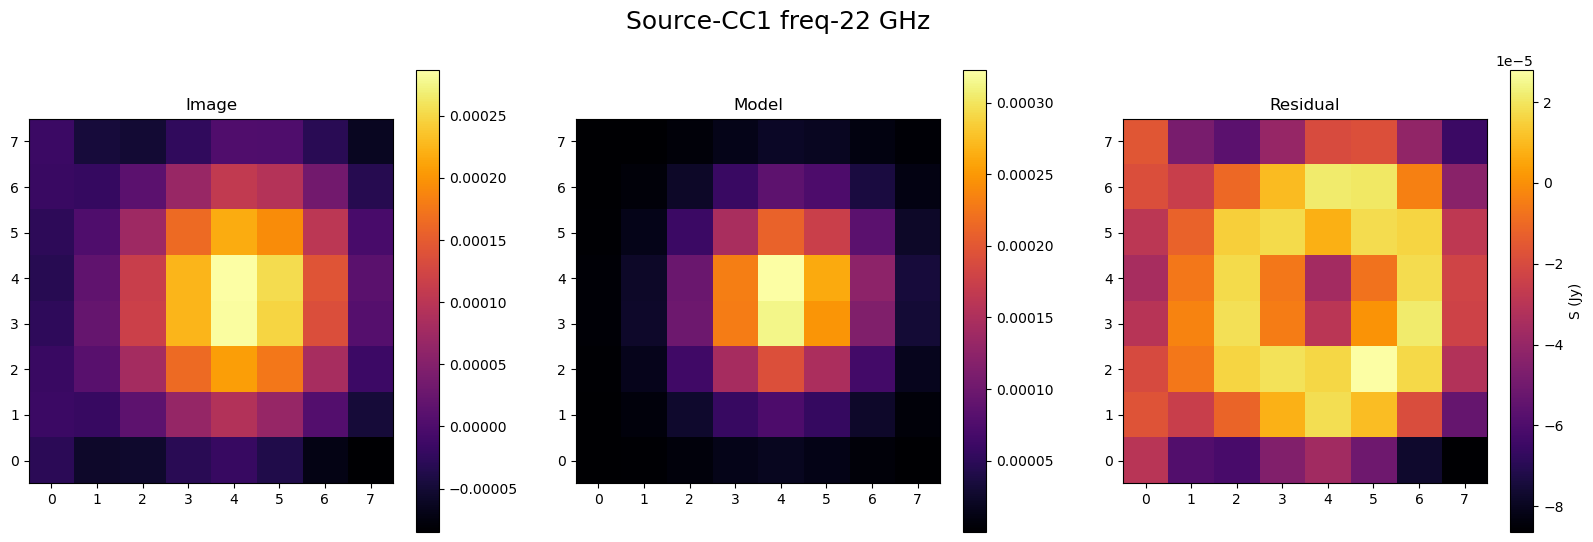

Parameter Error

Amplitude

3.381155236e-04 1.007333922e-04

x_mean

4.939095581e+03 4.048591057e-01

y_mean

4.932569758e+03 4.387020824e-01

x_stddev

1.349606058e+00 4.034727373e-01

y_stddev

1.485471079e+00 4.438114811e-01

theta

2.855111540e+00 2.194016295e+00

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93836675, 14.49733973)>


In [67]:
directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor.fits'



# d2
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=5219, y=4959, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=12, freq='22 GHz', source_name='d2')

# CB1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=4979, y=5000, x_stddev=5, y_stddev=4, theta=np.pi/6, 
                                          size=10, freq='22 GHz', source_name='CB1')

# CA3
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=4948, y=5015, x_stddev=3, y_stddev=3, theta=np.pi/4, 
                                          size=6, freq='22 GHz', source_name='CA3')


# This source does not fit well do to its close proximity to CA3
# CA2
# ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
#                                           maser_table=ca3_positions,
#                                           amplitude=0.001, x=4949, y=5021, x_stddev=2.5, y_stddev=2.5, theta=np.pi, 
#                                           size=4, freq='22 GHz', source_name='CA2')


# CA1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=.001, x=4929, y=5023, x_stddev=2.5, y_stddev=2.5, theta=np.pi/4, 
                                          size=5, freq='22 GHz', source_name='CA1')

# CC1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=.001, x=4939, y=4933, x_stddev=3.5, y_stddev=3.5, theta=np.pi, 
                                          size=4, freq='22 GHz', source_name='CC1')

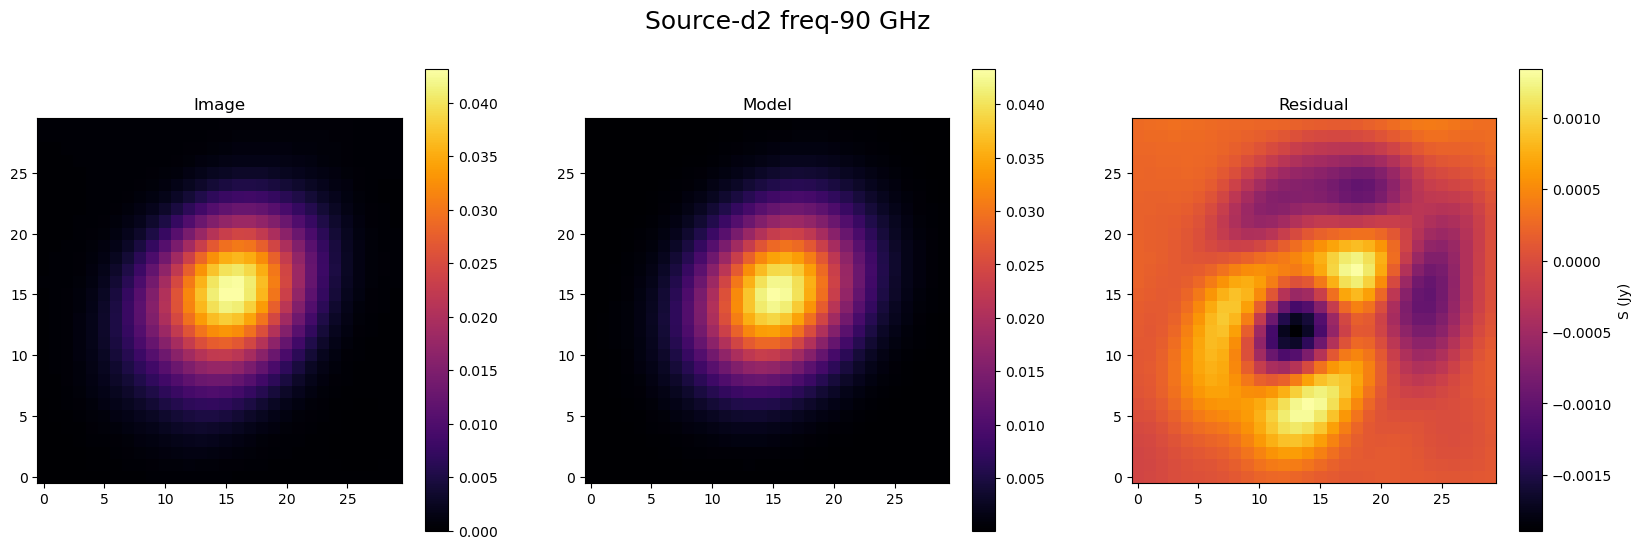

Parameter Error

Amplitude

4.337481287e-02 5.438359851e-04

x_mean

7.628289822e+03 5.417352014e-02

y_mean

7.226076096e+03 5.667732987e-02

x_stddev

3.929658851e+00 4.926936577e-02

y_stddev

4.86505194e+00 6.100794030e-02

theta

5.605907514e+00 4.121253377e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122784, 14.50395799)>


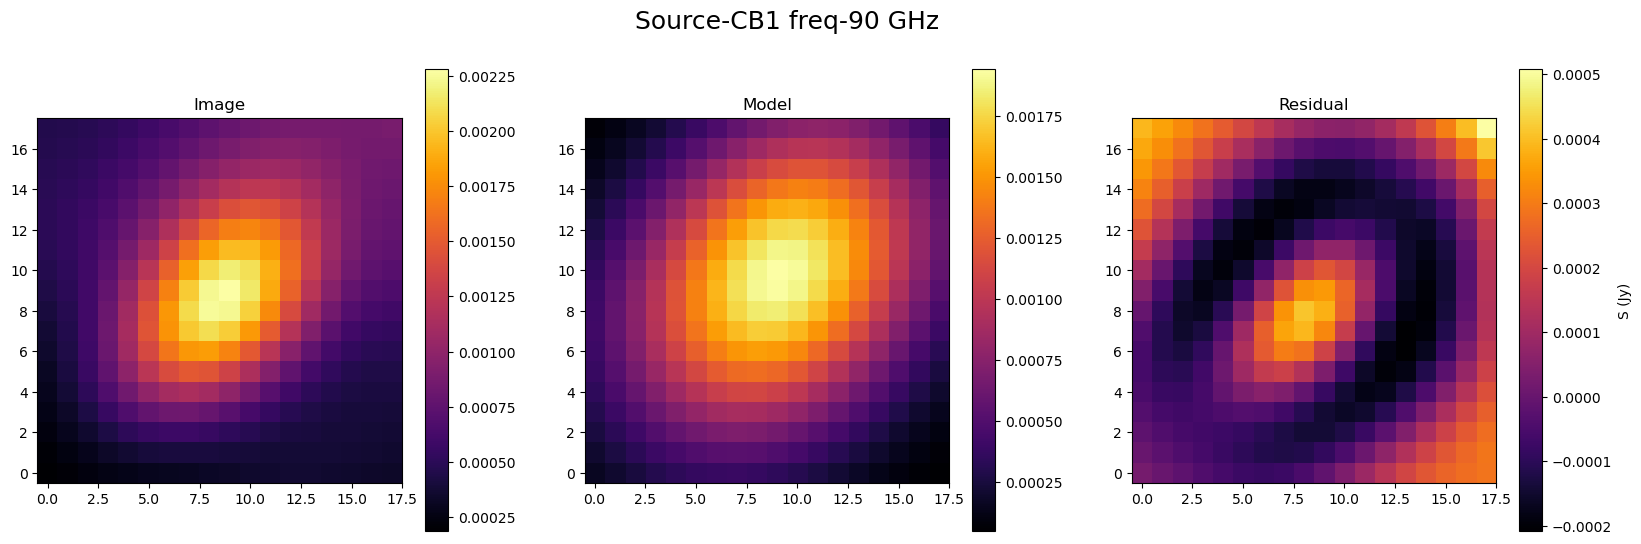

Parameter Error

Amplitude

1.946137177e-03 1.399176663e-04

x_mean

7.115096335e+03 3.740008372e-01

y_mean

7.311696814e+03 4.009524011e-01

x_stddev

5.963479773e+00 5.184912064e-01

y_stddev

4.541445557e+00 3.49592061e-01

theta

8.627674468e-01 2.193935941e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.9312272, 14.50395866)>


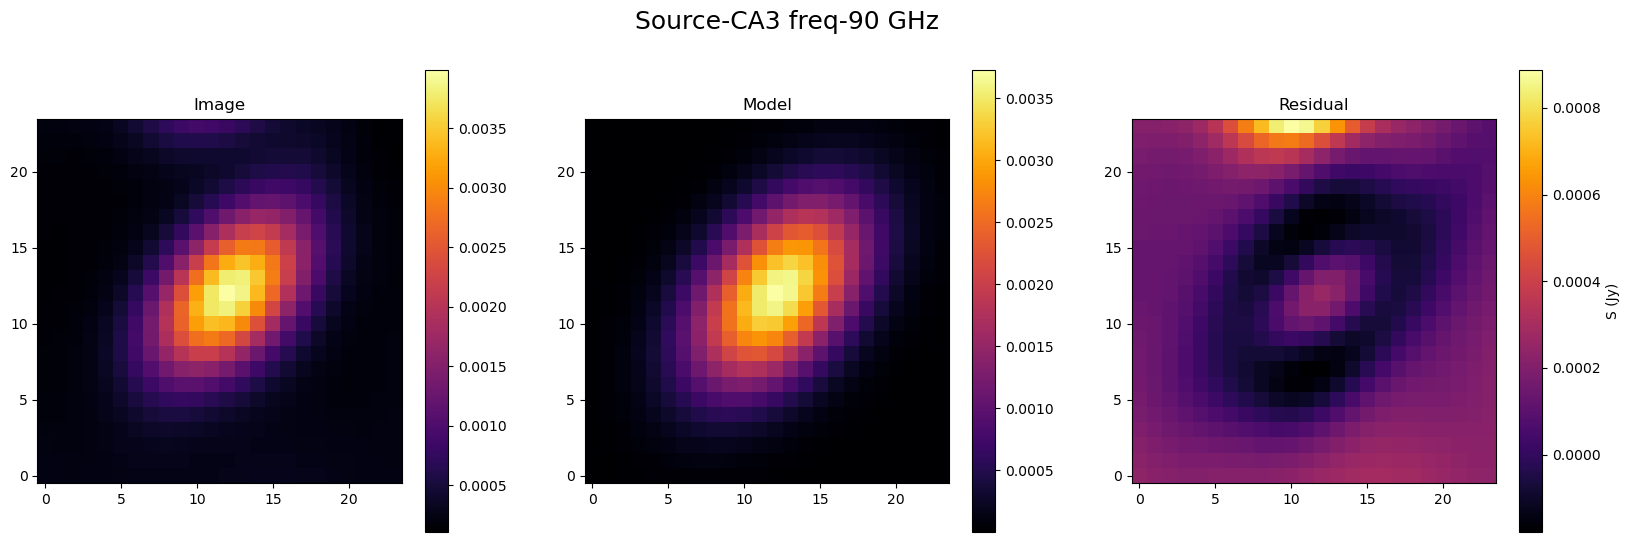

Parameter Error

Amplitude

3.735629069e-03 2.157947774e-04

x_mean

7.047214851e+03 2.180932279e-01

y_mean

7.342050777e+03 2.395058782e-01

x_stddev

2.95062429e+00 1.703505959e-01

y_stddev

4.773135508e+00 2.762791034e-01

theta

3.073549356e+01 8.180726181e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122751, 14.50395835)>


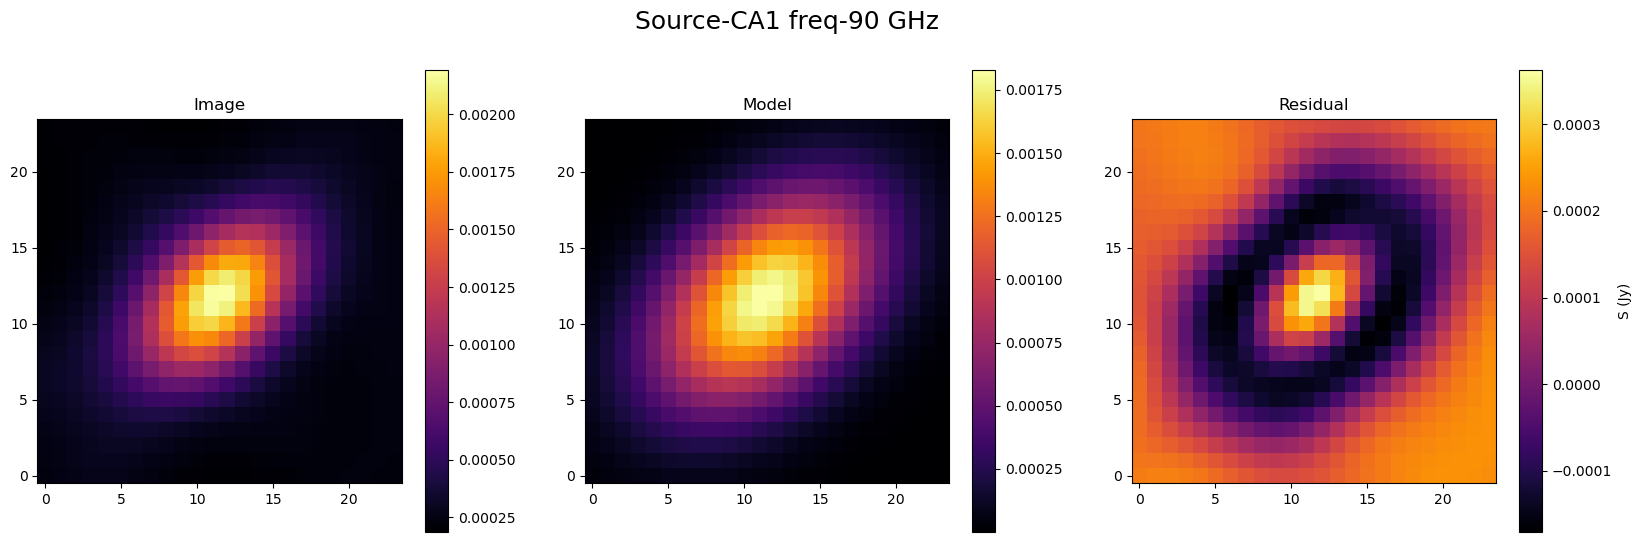

Parameter Error

Amplitude

1.844801783e-03 1.427231418e-04

x_mean

7.007362209e+03 3.77620799e-01

y_mean

7.360666333e+03 3.670566595e-01

x_stddev

5.727083351e+00 4.495891983e-01

y_stddev

3.724630907e+00 2.878365589e-01

theta

7.513250658e-01 1.245889880e-01

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122719, 14.5039586)>


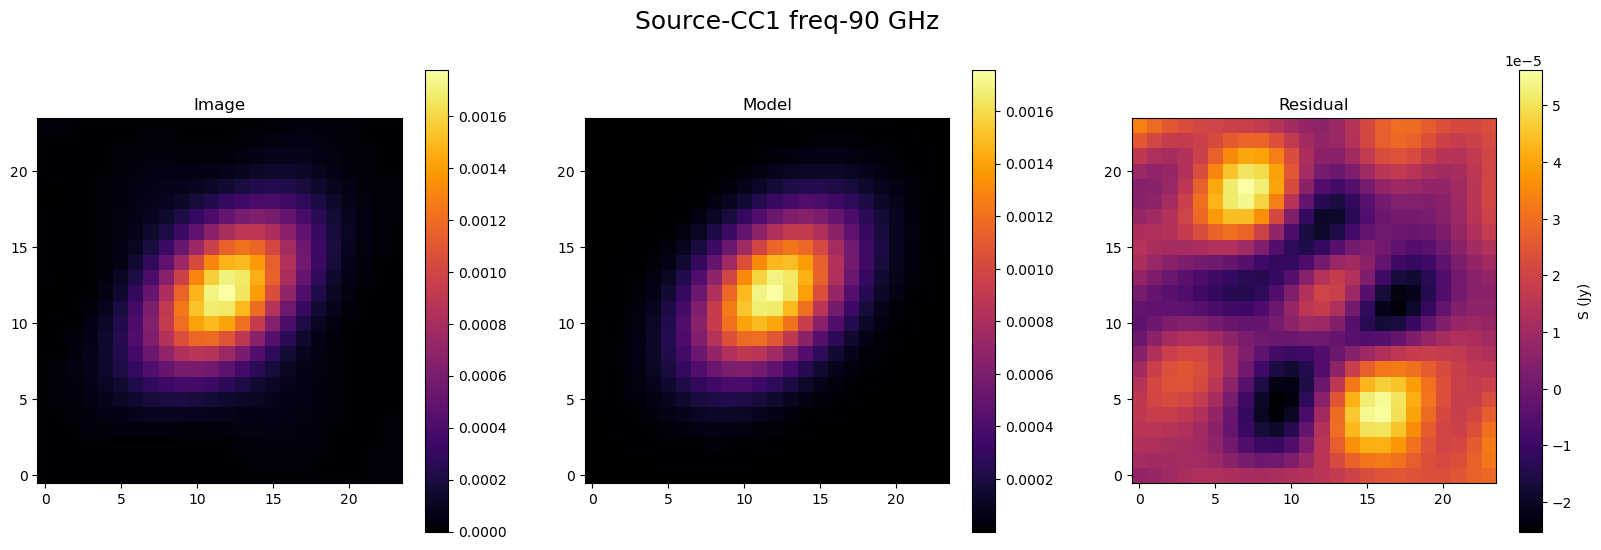

Parameter Error

Amplitude

1.7601722e-03 2.67955797e-05

x_mean

7.027845673e+03 5.216983386e-02

y_mean

7.167039935e+03 5.304767174e-02

x_stddev

2.643233125e+00 4.023741603e-02

y_stddev

4.111309150e+00 6.259470797e-02

theta

2.376289411e+00 2.359538724e-02

<SkyCoord (ICRS): (ra, dec) in deg
    (290.93122785, 14.50395799)>


In [68]:
directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/w51n.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'



# d2
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=5e-2, x=7628, y=7226, x_stddev=12, y_stddev=12, theta=11*np.pi/6, 
                                          size=15, freq='90 GHz', source_name='d2')

# CB1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=3e-2, x=7115, y=7311, x_stddev=4, y_stddev=6, theta=np.pi/4, 
                                          size=9, freq='90 GHz', source_name='CB1')

# CA3
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=1, x=7047, y=7342, x_stddev=9, y_stddev=9, theta=np.pi/4, 
                                          size=12, freq='90 GHz', source_name='CA3')


# This source does not fit well do to its close proximity to CA3
# CA2
# ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
#                                           maser_table=ca3_positions,
#                                           amplitude=0.001, x=4949, y=5021, x_stddev=2.5, y_stddev=2.5, theta=np.pi, 
#                                           size=4, freq='22 GHz', source_name='CA2')


# CA1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=.001, x=7008, y=7361, x_stddev=9, y_stddev=9, theta=np.pi/4, 
                                          size=12, freq='90 GHz', source_name='CA1')

# CC1
ca3_positions = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions,
                                          amplitude=.001, x=7028, y=7167, x_stddev=9, y_stddev=9, theta=np.pi, 
                                          size=12, freq='90 GHz', source_name='CC1')

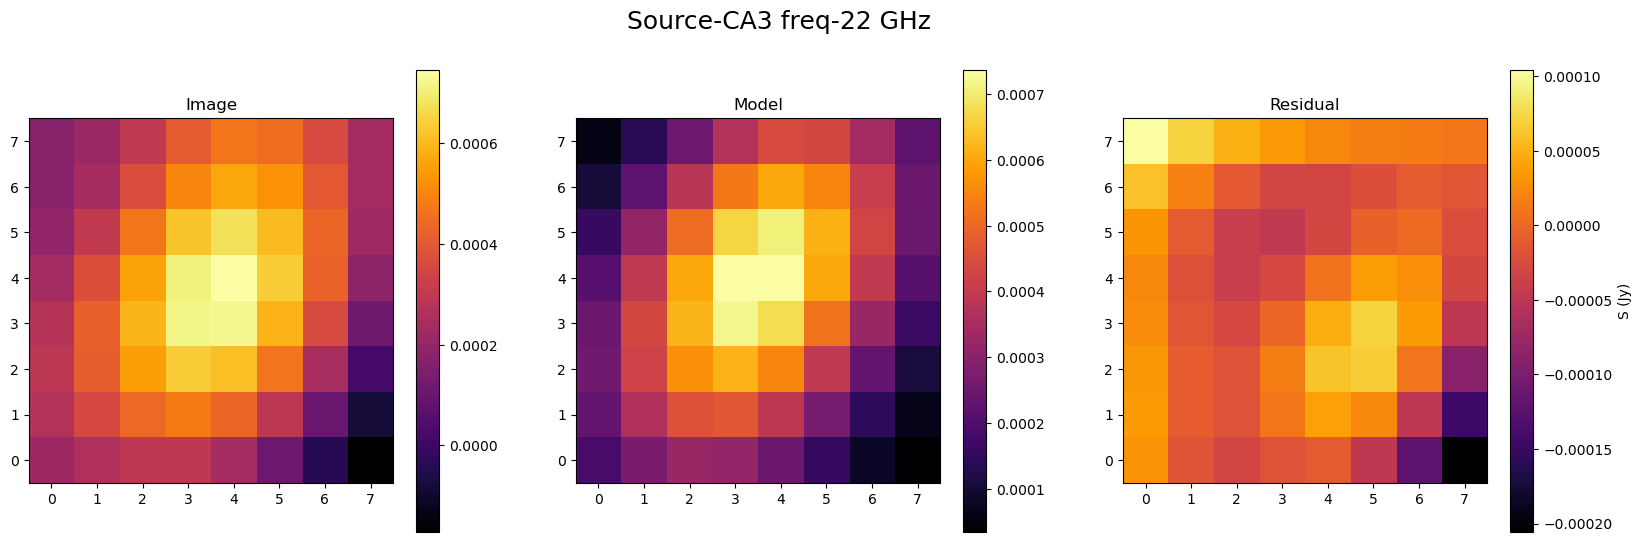

Parameter Error

Amplitude

7.564889207e-04 9.981267302e-05

x_mean

3.444824349e+02 3.097854847e-01

y_mean

4.159193021e+02 4.438426032e-01

x_stddev

3.261179270e+00 6.689154755e-01

y_stddev

2.044289294e+00 2.859738172e-01

theta

1.08016316e+00 2.433935022e-01

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (290.91845561, 14.51661838)>


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/1725868750.py:160: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  maser_table = pd.concat([maser_table, new_row], ignore_index=True)


In [69]:
ca3_positions_Kband_size800 = pd.DataFrame(columns=['source','freq', 'x_pix', 'y_pix', 'amplitude', 'amplitude_error', 
'x_mean', 'x_mean_error', 'y_mean', 'y_mean_error', 'x_mean_sky', 'x_mean_sky_error', 
'y_mean_sky', 'y_mean_sky_error', 
'ra_hms', 'dec_dms',
'SkyCoord', 'frame', 'header'])

directory3 = '/Volumes/GalagaResearch/Developer/masers/continuum/W51North_Kband_continuum_aug02.image.fits'

ca3_positions_Kband_size800 = fit_2dgaussian(table=True, cube=False, directory=directory3, 
                                          maser_table=ca3_positions_Kband_size800,
                                          amplitude=7.5e-4, x=345, y=416, x_stddev=2.5, y_stddev=3, theta=np.pi/4, 
                                          size=4, freq='22 GHz', source_name='CA3')

In [70]:
float(ca3_positions_Kband_size800['x_mean']), float(ca3_positions_Kband_size800['y_mean'])

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/2203283028.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(ca3_positions_Kband_size800['x_mean']), float(ca3_positions_Kband_size800['y_mean'])


(344.4824349, 415.9193021)

In [71]:
ca3_ALMA = ca3_positions[(ca3_positions['source'] == 'CA3') & (ca3_positions['freq'] == '90 GHz')]
ca3_VLA = ca3_positions[(ca3_positions['source'] == 'CA3') & (ca3_positions['freq'] == '22 GHz')]
# Delta RA
delta_ra = ca3_positions['x_mean_sky'] - float(ca3_ALMA['x_mean_sky'])
delta_dec = ca3_positions['y_mean_sky'] - float(ca3_ALMA['y_mean_sky'])

ca3_positions['delta_ra'] = delta_ra
ca3_positions['delta_dec'] = delta_dec

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/2567091512.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  delta_ra = ca3_positions['x_mean_sky'] - float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/2567091512.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  delta_dec = ca3_positions['y_mean_sky'] - float(ca3_ALMA['y_mean_sky'])


In [72]:
x_mean_sky_90 = ca3_positions[(ca3_positions['freq'] == '90 GHz')]['x_mean_sky']
x_mean_sky_22 = ca3_positions[(ca3_positions['freq'] == '22 GHz')]['x_mean_sky']
y_mean_sky_90 = ca3_positions[(ca3_positions['freq'] == '90 GHz')]['y_mean_sky']
y_mean_sky_22 = ca3_positions[(ca3_positions['freq'] == '22 GHz')]['y_mean_sky']

delta_ra_each = np.array(x_mean_sky_90) - np.array(x_mean_sky_22)
delta_dec_each = np.array(y_mean_sky_90) - np.array(y_mean_sky_22)

np.mean(delta_ra_each), np.mean(delta_dec_each)

(np.float64(-2.7079020128439877e-07), np.float64(2.7224150457527686e-06))

In [121]:
d2_22GHz_bool = (ca3_positions['source'] == 'd2') & (ca3_positions['freq'] == '22 GHz')
d2_90GHz_bool = (ca3_positions['source'] == 'd2') & (ca3_positions['freq'] == '90 GHz')

d2_22GHz_coord = ca3_positions.loc[d2_22GHz_bool, 'SkyCoord'].squeeze()
d2_90GHz_coord = ca3_positions.loc[d2_90GHz_bool, 'SkyCoord'].squeeze()

d2_22GHz_coord.separation(d2_90GHz_coord).arcsec

np.float64(0.025916974213478657)

In [122]:
def compute_separations(df, freq1='22 GHz', freq2='90 GHz'):
    """
    For each source in df that has rows with frequency freq1 and freq2,
    compute the angular separation between their 'SkyCoord' entries.
    
    Parameters:
      df : pandas.DataFrame
           DataFrame that must include, at minimum, the columns
           'source', 'freq', and 'SkyCoord'
      freq1 : str
             The first frequency (default '22 GHz')
      freq2 : str
             The second frequency (default '90 GHz')
             
    Returns:
      separation_df : pandas.DataFrame
           A new DataFrame with columns 'source' and 'separation_arcsec'
           containing the computed separations (in arcseconds) for each source.
    """
    results = []
    sources = df['source'].unique()
    for source in sources:
        group = df[df['source'] == source]
        # Check that there is at least one row for each frequency.
        if (group['freq'] == freq1).any() and (group['freq'] == freq2).any():
            # Use .squeeze() to extract a scalar SkyCoord if only one row per frequency
            coord1 = group.loc[group['freq'] == freq1, 'SkyCoord'].squeeze()
            coord2 = group.loc[group['freq'] == freq2, 'SkyCoord'].squeeze()
            # Compute the separation
            separation = coord1.separation(coord2).arcsec
            results.append({'source': source, 'separation_arcsec': separation})
    separation_df = pd.DataFrame(results)
    return separation_df

In [158]:
def compute_differences(df, freq1='22 GHz', freq2='90 GHz'):

    difference_distance_list = []

    sources = df['source'].unique()
    for source in sources:
        group = df[df['source'] == source]
        # Check that there is at least one row for each frequency.
        if (group['freq'] == freq1).any() and (group['freq'] == freq2).any():
            # Use .squeeze() to extract a scalar SkyCoord if only one row per frequency
            ra1 = group.loc[group['freq'] == freq1, 'x_mean_sky'].squeeze()
            dec1 = group.loc[group['freq'] == freq1, 'y_mean_sky'].squeeze()

            ra2 = group.loc[group['freq'] == freq2, 'x_mean_sky'].squeeze()
            dec2 = group.loc[group['freq'] == freq2, 'y_mean_sky'].squeeze()

            delta_ra = ra2 - ra1
            delta_dec = dec2 - dec1

            diff_distance = np.sqrt(delta_ra**2 + delta_dec**2) * u.deg.to(u.arcsec)

            difference_distance_list.append({'source': source, 'delta_distance_arcsec': diff_distance})

    difference_distance_df = pd.DataFrame(difference_distance_list)

    return difference_distance_df

In [159]:
#Separation between 22 GHz and 90 GHz

compute_separations(ca3_positions), compute_differences(ca3_positions)

(  source  separation_arcsec
 0     d2           0.025917
 1    CB1           0.012980
 2    CA3           0.009704
 3    CA1           0.008217
 4    CC1           0.011051,
   source  delta_distance_arcsec
 0     d2               0.025995
 1    CB1               0.013071
 2    CA3               0.009896
 3    CA1               0.008222
 4    CC1               0.011072)

In [163]:
np.mean(compute_separations(ca3_positions)['separation_arcsec']), np.mean(compute_differences(ca3_positions)['delta_distance_arcsec'])

(np.float64(0.013573764631442118), np.float64(0.01365116909795248))

In [151]:
ca3_positions

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,...,x_mean_sky_error,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header,delta_ra,delta_dec
0,d2,22 GHz,5219,4959,1.151836792e-02,2.994631787e-04,5.218610551e+03,6.144036822e-02,4.95918845e+03,7.060362261e-02,...,290.938368,14.518002,14.497338,19:23:39.8182,14:31:04.8078,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.001165,-0.000232
1,CB1,22 GHz,4979,5000,4.441095342e-04,3.220142691e-04,4.979244419e+03,9.860078561e-01,5.000022628e+03,1.336618399e+00,...,290.938364,14.518172,14.497343,19:23:40.0654,14:31:05.4203,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000135,-0.000062
2,CA3,22 GHz,4948,5015,8.286839918e-04,1.202250481e-04,4.948462022e+03,2.543054466e-01,5.015367510e+03,4.805084936e-01,...,290.938367,14.518236,14.497340,19:23:40.0972,14:31:05.6505,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000002,0.000002
3,CA1,22 GHz,4929,5023,6.131044792e-04,4.511103321e-05,4.929290048e+03,2.572806573e-01,5.023102075e+03,2.51185041e-01,...,290.938367,14.518268,14.497339,19:23:40.1170,14:31:05.7665,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000080,0.000034
4,CC1,22 GHz,4939,4933,3.381155236e-04,1.007333922e-04,4.939095581e+03,4.048591057e-01,4.932569758e+03,4.387020824e-01,...,290.938367,14.517891,14.497340,19:23:40.1069,14:31:04.4085,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000038,-0.000343
5,d2,90 GHz,7628,7226,4.337481287e-02,5.438359851e-04,7.628289822e+03,5.417352014e-02,7.226076096e+03,5.667732987e-02,...,290.931228,14.518009,14.503958,19:23:39.8176,14:31:04.8325,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.001167,-0.000226
6,CB1,90 GHz,7115,7311,1.946137177e-03,1.399176663e-04,7.115096335e+03,3.740008372e-01,7.311696814e+03,4.009524011e-01,...,290.931227,14.518176,14.503959,19:23:40.0650,14:31:05.4319,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000136,-0.000059
7,CA3,90 GHz,7047,7342,3.735629069e-03,2.157947774e-04,7.047214851e+03,2.180932279e-01,7.342050777e+03,2.395058782e-01,...,290.931228,14.518235,14.503958,19:23:40.0978,14:31:05.6444,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000000,0.000000
8,CA1,90 GHz,7008,7361,1.844801783e-03,1.427231418e-04,7.007362209e+03,3.77620799e-01,7.360666333e+03,3.670566595e-01,...,290.931227,14.518271,14.503959,19:23:40.1170,14:31:05.7747,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000080,0.000036
9,CC1,90 GHz,7028,7167,1.7601722e-03,2.67955797e-05,7.027845673e+03,5.216983386e-02,7.167039935e+03,5.304767174e-02,...,290.931228,14.517894,14.503958,19:23:40.1071,14:31:04.4193,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000039,-0.000340


In [75]:
ca3_positions

,source,freq,x_pix,y_pix,amplitude,amplitude_error,x_mean,x_mean_error,y_mean,y_mean_error,...,x_mean_sky_error,y_mean_sky,y_mean_sky_error,ra_hms,dec_dms,SkyCoord,frame,header,delta_ra,delta_dec
0,d2,22 GHz,5219,4959,1.151836792e-02,2.994631787e-04,5.218610551e+03,6.144036822e-02,4.95918845e+03,7.060362261e-02,...,290.938368,14.518002,14.497338,19:23:39.8182,14:31:04.8078,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.001165,-0.000232
1,CB1,22 GHz,4979,5000,4.441095342e-04,3.220142691e-04,4.979244419e+03,9.860078561e-01,5.000022628e+03,1.336618399e+00,...,290.938364,14.518172,14.497343,19:23:40.0654,14:31:05.4203,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000135,-0.000062
2,CA3,22 GHz,4948,5015,8.286839918e-04,1.202250481e-04,4.948462022e+03,2.543054466e-01,5.015367510e+03,4.805084936e-01,...,290.938367,14.518236,14.497340,19:23:40.0972,14:31:05.6505,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,-0.000002,0.000002
3,CA1,22 GHz,4929,5023,6.131044792e-04,4.511103321e-05,4.929290048e+03,2.572806573e-01,5.023102075e+03,2.51185041e-01,...,290.938367,14.518268,14.497339,19:23:40.1170,14:31:05.7665,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000080,0.000034
4,CC1,22 GHz,4939,4933,3.381155236e-04,1.007333922e-04,4.939095581e+03,4.048591057e-01,4.932569758e+03,4.387020824e-01,...,290.938367,14.517891,14.497340,19:23:40.1069,14:31:04.4085,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 2\nCTYPE :...,0.000038,-0.000343
5,d2,90 GHz,7628,7226,4.337481287e-02,5.438359851e-04,7.628289822e+03,5.417352014e-02,7.226076096e+03,5.667732987e-02,...,290.931228,14.518009,14.503958,19:23:39.8176,14:31:04.8325,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.001167,-0.000226
6,CB1,90 GHz,7115,7311,1.946137177e-03,1.399176663e-04,7.115096335e+03,3.740008372e-01,7.311696814e+03,4.009524011e-01,...,290.931227,14.518176,14.503959,19:23:40.0650,14:31:05.4319,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,-0.000136,-0.000059
7,CA3,90 GHz,7047,7342,3.735629069e-03,2.157947774e-04,7.047214851e+03,2.180932279e-01,7.342050777e+03,2.395058782e-01,...,290.931228,14.518235,14.503958,19:23:40.0978,14:31:05.6444,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000000,0.000000
8,CA1,90 GHz,7008,7361,1.844801783e-03,1.427231418e-04,7.007362209e+03,3.77620799e-01,7.360666333e+03,3.670566595e-01,...,290.931227,14.518271,14.503959,19:23:40.1170,14:31:05.7747,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000080,0.000036
9,CC1,90 GHz,7028,7167,1.7601722e-03,2.67955797e-05,7.027845673e+03,5.216983386e-02,7.167039935e+03,5.304767174e-02,...,290.931228,14.517894,14.503958,19:23:40.1071,14:31:04.4193,"<SkyCoord (ICRS): (ra, dec) in deg\n (290.9...",icrs,WCS Keywords\n\nNumber of WCS axes: 4\nCTYPE :...,0.000039,-0.000340


In [76]:
float(ca3_ALMA['x_mean_sky'])

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/3816414553.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(ca3_ALMA['x_mean_sky'])


290.9170739774408

In [77]:
ca3_ALMA['x_mean_sky']

7    290.917074
Name: x_mean_sky, dtype: float64

In [78]:
pwd

'/Volumes/GalagaResearch/Developer/masers/W51/W51-Masers-and-Starforming-Regions/notebooks/FK5_ICRS_offsets'

In [79]:
float(ca3_ALMA['x_mean_sky'])

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/3816414553.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(ca3_ALMA['x_mean_sky'])


290.9170739774408

In [80]:
ca3_positions.to_csv('offset_sources.csv', index=False)

### Edit Headers of VLA files

In [ ]:
import glob
import os

In [90]:
# Change K Band FK5 to ICRS

all_fits = glob.glob('/Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor.fits')

for fits_path in all_fits:
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        hdr['RADESYS'] = 'ICRS'
    
        if 'EQUINOX' in hdr:
            del hdr['EQUINOX']

        # ALMA ICRS CA3 physical coordinates 
        hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
        hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])

        # VLA CA3 pixel coordinates
        hdr['CRPIX1'] = float(ca3_VLA['x_mean'])
        hdr['CRPIX2'] = float(ca3_VLA['y_mean'])

        base_name = os.path.splitext(fits_path)[0]  # Remove the .fits part
        new_fits_file = f"{base_name}_ICRS_CRVAL_CA3_crval_change.fits"

        hdul.writeto(new_fits_file, overwrite=True)


    print(f"Modified and saved: {new_fits_file}")

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/1206931739.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/1206931739.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/1206931739.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRPIX1'] = float(ca3_VLA['x_mean'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/1206931739.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in 

Modified and saved: /Volumes/GalagaResearch/Developer/masers/continuum/modified_VLA/W51_North_KbandAarray_cont_spws_continuum_cal_clean_2terms_robust0_selfcal3.image.tt0.pbcor_ICRS_CRVAL_CA3_crval_change.fits


In [91]:
# Change K Band FK5 to ICRS

all_fits = glob.glob('/Volumes/GalagaResearch/Developer/masers/continuum/W51North_Kband_continuum_aug02.image.fits')

for fits_path in all_fits:
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        hdr['RADESYS'] = 'ICRS'
    
        if 'EQUINOX' in hdr:
            del hdr['EQUINOX']

        # ALMA ICRS CA3 physical coordinates 
        hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
        hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])

        # VLA CA3 pixel coordinates
        hdr['CRPIX1'] = float(ca3_positions_Kband_size800['x_mean'])
        hdr['CRPIX2'] = float(ca3_positions_Kband_size800['y_mean'])

        base_name = os.path.splitext(fits_path)[0]  # Remove the .fits part
        new_fits_file = f"{base_name}_ICRS_CRVAL_CA3_crval_change.fits"

        hdul.writeto(new_fits_file, overwrite=True)


    print(f"Modified and saved: {new_fits_file}")

Modified and saved: /Volumes/GalagaResearch/Developer/masers/continuum/W51North_Kband_continuum_aug02.image_ICRS_CRVAL_CA3_crval_change.fits


/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/530818468.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/530818468.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/530818468.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRPIX1'] = float(ca3_positions_Kband_size800['x_mean'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/530818468.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise

In [95]:
# Masers

# /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/

all_fits = glob.glob('/Volumes/GalagaResearch/Developer/masers/W51/FITS/original/*_aug_02.fits')

for fits_path in all_fits:
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        hdr['RADESYS'] = 'ICRS'
    
        if 'EQUINOX' in hdr:
            del hdr['EQUINOX']

        # ALMA ICRS CA3 physical coordinates 
        hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
        hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])

        # VLA CA3 pixel coordinates
        # hdr['CRPIX1'] = int(float(ca3_VLA['x_mean']))
        # hdr['CRPIX2'] = int(float(ca3_VLA['y_mean']))
        
        hdr['CRPIX1'] = float(ca3_positions_Kband_size800['x_mean'])
        hdr['CRPIX2'] = float(ca3_positions_Kband_size800['y_mean'])

        base_name = os.path.splitext(fits_path)[0]  # Remove the .fits part
        new_fits_file = f"{base_name}_ICRS_CRVAL_CA3_crval_change.fits"

        hdul.writeto(new_fits_file, overwrite=True)

    print(f"Modified and saved: {new_fits_file}")

/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/3295870171.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL1'] = float(ca3_ALMA['x_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/3295870171.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRVAL2'] = float(ca3_ALMA['y_mean_sky'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/3295870171.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hdr['CRPIX1'] = float(ca3_positions_Kband_size800['x_mean'])
/var/folders/31/0kzd8c111cj87_n2y45gkb700000gn/T/ipykernel_57262/3295870171.py:24: FutureWarning: Calling float on a single element Series is deprecated and will r

Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_53_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_6_corrected11_1_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_38_corrected6_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_50_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_28_corrected31_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_56_corrected2_aug_02_ICRS_CRVAL_CA3_crval_change.fits
Modified and saved: /Volumes/GalagaResearch/Developer/masers/W51/FITS/original/W51North_spw_28_corrected40_aug_02_ICRS_CR